# Meet the wines: curation and exploration

Goal: understand the raw data well enough to know what a good price prediction would even mean.

The dataset is [`spawn99/wine-reviews`](https://huggingface.co/datasets/spawn99/wine-reviews):
Wine Enthusiast tasting notes with a critic score (`points`), a price, and geography. Two Kaggle
scrapes merged together, so expect duplicates and missing prices.

Its train/validation/test split is one arbitrary partition of that single scrape, so all three are
concatenated here and re-split at the end -- otherwise a third of the reviews go unused, and
duplicate notes spanning the upstream splits survive deduplication.

In [25]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from datasets import concatenate_datasets, load_dataset

from pricer.curate import balance, deduplicate, holdout, price_histogram
from pricer.items import Wine
from pricer.loaders import RAW_DATASET
from pricer.parser import compose, parse

raw = concatenate_datasets(list(load_dataset(RAW_DATASET).values()))
raw

Dataset({
    features: ['country', 'description', 'designation', 'points', 'price', 'province', 'region_1', 'region_2', 'variety', 'winery', 'taster_name', 'taster_twitter_handle', 'title'],
    num_rows: 280901
})

### One row, in full

In [26]:
for key, value in raw[0].items():
    print(f"{key:>14}: {value}")

       country: Italy
   description: This ruby-hued blend of Nerello Mascalese and Nerello Cappuccio conveys aromas of bright berry, intense mint and a whiff of baking spice. The vibrant palate offers sour cherry, mineral and cinnamon flavors alongside fresh acidity.
   designation: Pietralava
        points: 88
         price: None
      province: Sicily & Sardinia
      region_1: Etna
      region_2: None
       variety: Red Blend
        winery: Antichi Vinai 1877
   taster_name: Kerin O’Keefe
taster_twitter_handle: @kerinokeefe
         title: Antichi Vinai 1877 2013 Pietralava Red (Etna)


### How much of the raw data is usable?

`parse` rejects a row when the price is missing, the price is outside \$4-\$500, or the tasting note
is under 100 characters. Everything else becomes a `Wine`.

In [27]:
parsed = [parse(row) for row in raw]
wines = [wine for wine in parsed if wine]
print(f"{len(raw):,} raw rows -> {len(wines):,} usable wines ({len(wines) / len(raw):.0%})")

280,901 raw rows -> 255,856 usable wines (91%)


### Duplicates

The merge left the same tasting note in the file many times over. Left alone, the identical wine
appears in both train and test, and every model looks better than it is.

In [28]:
notes = Counter(wine.description for wine in wines)
print(f"{len(notes):,} distinct notes among {len(wines):,} wines")
for note, count in notes.most_common(3):
    print(f"\n{count} copies: {note[:110]}...")

155,262 distinct notes among 255,856 wines

6 copies: Strong mint and menthol aromatics give way to intense fresh-cut cedar flavors. There's just too much wood for ...

6 copies: This is your quintessential simple quaff among brut cavas. It's clean, lime-tinged and soda-like on the nose, ...

6 copies: A dusty, cigar-smoke character on the nose of this blend of 52% Syrah and 48% Cabernet Sauvignon spices up aro...


In [41]:
wines = deduplicate(wines)

155,262 wines after dropping 100,594 duplicate tasting notes


### The target

Price is log-normal. The median bottle is cheap and the tail is long, which is why the metric that
matters here is RMSLE (error in *relative* terms) rather than raw-dollar MSE -- being \$20 out on a
\$25 bottle is a disaster, on a \$400 bottle it is noise.

median $25  mean $34  p95 $85


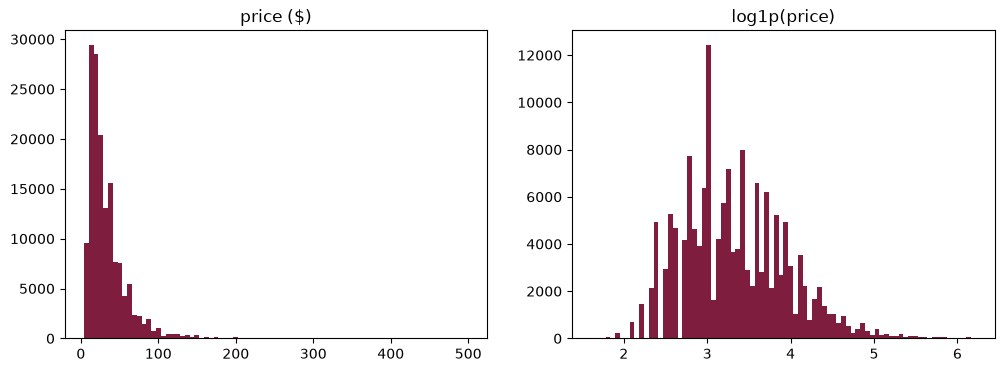

In [42]:
prices = np.array([wine.price for wine in wines])
print(f"median ${np.median(prices):,.0f}  mean ${prices.mean():,.0f}  p95 ${np.percentile(prices, 95):,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(prices, bins=80, color="#7f1d3f")
axes[0].set_title("price ($)")
axes[1].hist(np.log1p(prices), bins=80, color="#7f1d3f")
axes[1].set_title("log1p(price)")
plt.show()

### Does the critic score explain the price?

Partly -- and that is exactly why `points` is kept out of the text the models read by default. It is
a strong, easy proxy that would let a model skip reading the tasting note. Turn it back on with
`compose(wine, fields=(..., "points"))` when you want to measure how much of the signal it carries.

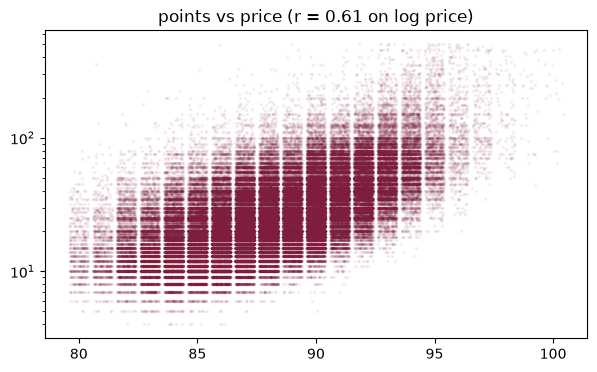

In [43]:
points = np.array([wine.points for wine in wines])
correlation = np.corrcoef(points, np.log1p(prices))[0, 1]
plt.figure(figsize=(7, 4))
plt.scatter(points + np.random.uniform(-0.4, 0.4, len(points)), prices, s=2, alpha=0.05, color="#7f1d3f")
plt.yscale("log")
plt.title(f"points vs price (r = {correlation:.2f} on log price)")
plt.show()

### Where the wines come from, and what they are

In [44]:
facets = {
    "country": lambda wine: wine.country,
    "variety": lambda wine: wine.variety,
    "taster": lambda wine: wine.taster,
}
for label, pick in facets.items():
    values = [pick(wine) or "unknown" for wine in wines]
    counts = Counter(values)
    print(f"\n{label}: {len(counts):,} distinct")
    for name, count in counts.most_common(8):
        median = np.median([wine.price for wine, value in zip(wines, values, strict=True) if value == name])
        print(f"  {name[:28]:<30}{count:>7,}   median ${median:>6,.0f}")


country: 49 distinct
  US                             69,396   median $    30
  Italy                          21,219   median $    28
  France                         20,831   median $    25
  Spain                           8,684   median $    18
  Chile                           6,060   median $    15
  Portugal                        5,750   median $    17
  Argentina                       5,401   median $    16
  Australia                       4,298   median $    20

variety: 746 distinct
  Pinot Noir                     15,852   median $    42
  Chardonnay                     14,568   median $    25
  Cabernet Sauvignon             12,946   median $    35
  Red Blend                      10,527   median $    28
  Sauvignon Blanc                 6,507   median $    18
  Bordeaux-style Red Blend        6,399   median $    30
  Riesling                        6,251   median $    22
  Syrah                           5,684   median $    33

taster: 20 distinct
  unknown             

### Tasting notes are short

A few hundred characters each, so a fine-tune sees the whole note comfortably inside a small context.

median 240 chars, p99 432 chars


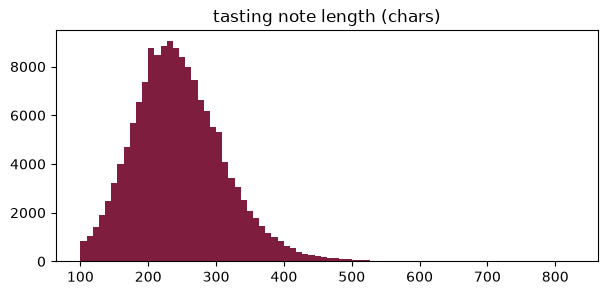

In [45]:
lengths = np.array([len(wine.description) for wine in wines])
print(f"median {np.median(lengths):.0f} chars, p99 {np.percentile(lengths, 99):.0f} chars")
plt.figure(figsize=(7, 3))
plt.hist(lengths, bins=80, color="#7f1d3f")
plt.title("tasting note length (chars)")
plt.show()

### Hold out the test set first, then balance

Trained on the raw distribution a model learns that guessing \$25 is nearly always safe. Capping how
many wines each log-price bin may contribute flattens the target and forces the model to read.

Order matters. Validation and test come out of the deduplicated pool *before* balancing, so the cap
only ever changes the training set -- balance first and every cap would be scored on a differently
shaped test set, mixing "more data" with "easier exam". The unbalanced test set is also the honest
one: wines in a shop are not uniform in price.

The trade is volume: the top bins hold only a few hundred wines each, so a *perfectly* flat set would
be tiny. `cap=10_000` keeps a bit over half the data. **Experiment:** rerun with `cap=20_000` and
compare RMSLE on the expensive half of the test set -- now a fair comparison.

In [46]:
price_histogram(wines)

$     4-     6      95 
$     6-     8     945 #
$     8-    11   8,498 ##########
$    11-    15  17,058 ###################
$    15-    20  35,072 ########################################
$    20-    27  22,446 ##########################
$    27-    37  23,464 ###########################
$    37-    49  19,057 ######################
$    49-    66  14,806 #################
$    66-    88   7,042 ########
$    88-   118   3,446 ####
$   118-   157   1,895 ##
$   157-   210     696 #
$   210-   281     373 
$   281-   375     218 
$   375-   500     151 


In [49]:
pool, val, test = holdout(wines)
train = balance(pool, cap=10_000)
price_histogram(train)

pool=151,262 val=2,000 test=2,000
Capped at 10,000 per bin: 82,786 of 151,262 wines, median price $29 (was $25)
$     4-     6      91 
$     6-     8     930 ####
$     8-    11   8,299 #################################
$    11-    15  10,000 ########################################
$    15-    20  10,000 ########################################
$    20-    27  10,000 ########################################
$    27-    37  10,000 ########################################
$    37-    49  10,000 ########################################
$    49-    66  10,000 ########################################
$    66-    88   6,861 ###########################
$    88-   118   3,359 #############
$   118-   157   1,835 #######
$   157-   210     688 ###
$   210-   281     366 #
$   281-   375     212 #
$   375-   500     145 #


### What a model actually reads

In [50]:
print(train[0].full)
print("\n--- price:", train[0].price)
print("len(train):", len(train))

Vintage: 2006
Variety: Shiraz
Country: Australia
Province: Australia Other
Region: South Eastern Australia
Tasting note: Banrock Station's 2006 Shiraz is a throwback to the kind of super value Australian wines used to provide with more regularity. For $5, consumers get a decently textured, supple wine with plenty of forward blueberry and plum fruit and touches of chocolate and pepper. Look for it by the glass or buy it by the case for entertaining on a budget.

--- price: 5.0
len(train): 82786


In [ ]:
# The same wine with the leaky fields switched on, for comparison
print(compose(train[0], fields=("vintage", "variety", "country", "region", "winery", "points", "note")))

### Cache the splits

In [ ]:
Wine.save_local(train=train, val=val, test=test)

Next: `scripts/baselines.py` fits the classical ladder on this cache, and
`notebooks/2_baseline_ladder.ipynb` walks through what each rung is worth.